# Analyse des avis et alertes ANSSI - Etapes 5 et 6

Ce notebook charge `donnees_consolidees.csv` (produit par `pipeline_anssi.py`),
puis realise :
- **Etape 5** : exploration et visualisations
- **Etape 6** : deux modeles de Machine Learning (non supervise + supervise) avec validation

## 0. Chargement des donnees

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("donnees_consolidees.csv")
print("Dimensions :", df.shape)
df.head()

Dimensions : (1351, 16)


,ID ANSSI,Titre ANSSI,Type,Date,CVE,Score CVSS,Base Severity,CWE,Score EPSS,Niveau EPSS,Priorite,Lien,Description,Editeur,Produit,Versions affectees
0,CERTFR-2023-ALE-007,[MàJ] Vulnérabilité dans Zimbra Collaboration ...,Alerte,2023-07-17,CVE-2023-37580,NaN,Inconnue,NaN,0.93918,Eleve,NaN,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Zimbra Collaboration (ZCS) 8 before 8.8.15 Pat...,NaN,NaN,NaN
1,CERTFR-2023-ALE-008,[MàJ] Vulnérabilité dans Citrix NetScaler ADC ...,Alerte,2023-07-19,CVE-2023-3519,9.8,Critique,CWE-94,0.93363,Eleve,9.15,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Unauthenticated remote code execution,Citrix,NetScaler ADC,"13.1, 13.0, 13.1-FIPS, 12.1-FIPS, 12.1-NDcPP"
2,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim,Alerte,2023-10-02,CVE-2023-42118,7.5,Elevee,CWE-191,0.03014,Faible,0.23,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Exim libspf2 Integer Underflow Remote Code Exe...,Exim,libspf2,exim 4.96-RC0-14-24b8ed847-XX
3,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim,Alerte,2023-10-02,CVE-2023-42116,8.1,Elevee,CWE-121,0.06734,Faible,0.55,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Exim SMTP Challenge Stack-based Buffer Overflo...,Exim,Exim,exim 4.95
4,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim,Alerte,2023-10-02,CVE-2023-42115,9.8,Critique,CWE-787,0.65812,Eleve,6.45,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,Exim AUTH Out-Of-Bounds Write Remote Code Exec...,Exim,Exim,exim 4.95


## Etape 5 - Exploration et visualisation

### 5.1 Exploration

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID ANSSI            1351 non-null   str    
 1   Titre ANSSI         1351 non-null   str    
 2   Type                1351 non-null   str    
 3   Date                1351 non-null   str    
 4   CVE                 1351 non-null   str    
 5   Score CVSS          665 non-null    float64
 6   Base Severity       1351 non-null   str    
 7   CWE                 765 non-null    str    
 8   Score EPSS          1339 non-null   float64
 9   Niveau EPSS         1351 non-null   str    
 10  Priorite            665 non-null    float64
 11  Lien                1351 non-null   str    
 12  Description         1339 non-null   str    
 13  Editeur             1327 non-null   str    
 14  Produit             1333 non-null   str    
 15  Versions affectees  1325 non-null   str    
dtypes: float64(3), st

In [23]:
df[['Score CVSS', 'Score EPSS']].describe()

,Score CVSS,Score EPSS
count,665.000000,1339.000000
mean,7.314286,0.029574
std,1.576309,0.149211
min,0.400000,0.000030
25%,6.500000,0.000210
50%,7.800000,0.000400
75%,8.100000,0.000820
max,10.000000,0.944120


In [24]:
# Nombre de valeurs manquantes par colonne
df.isna().sum()

ID ANSSI                0
Titre ANSSI             0
Type                    0
Date                    0
CVE                     0
Score CVSS            686
Base Severity           0
CWE                   586
Score EPSS             12
Niveau EPSS             0
Priorite              686
Lien                    0
Description            12
Editeur                24
Produit                18
Versions affectees     26
dtype: int64

### 5.2 Distribution des scores CVSS

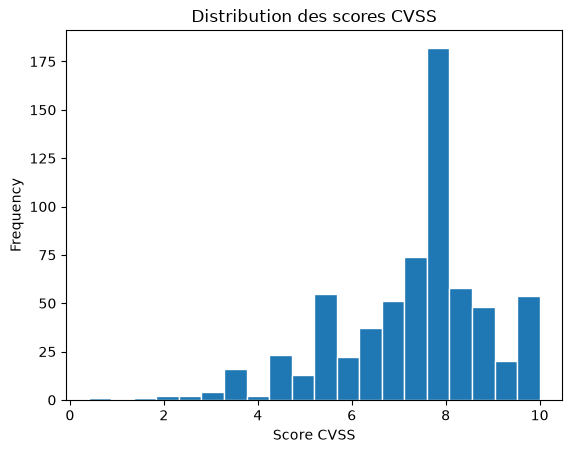

In [25]:
df["Score CVSS"].plot(kind="hist", bins=20, edgecolor="white")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.show()

### 5.3 Types de failles les plus frequents (CWE)

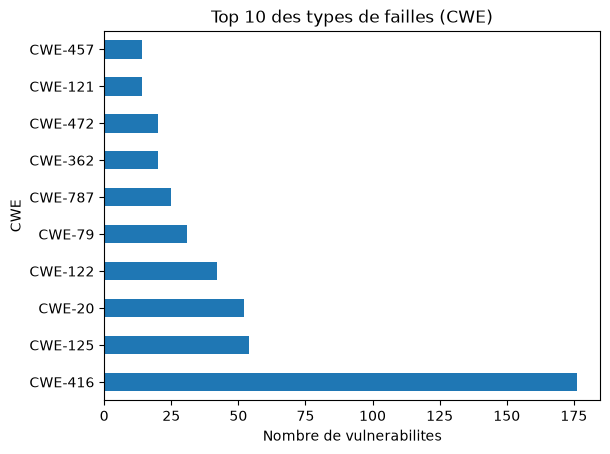

In [26]:
df["CWE"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 des types de failles (CWE)")
plt.xlabel("Nombre de vulnerabilites")
plt.show()

### 5.4 Editeurs les plus touches

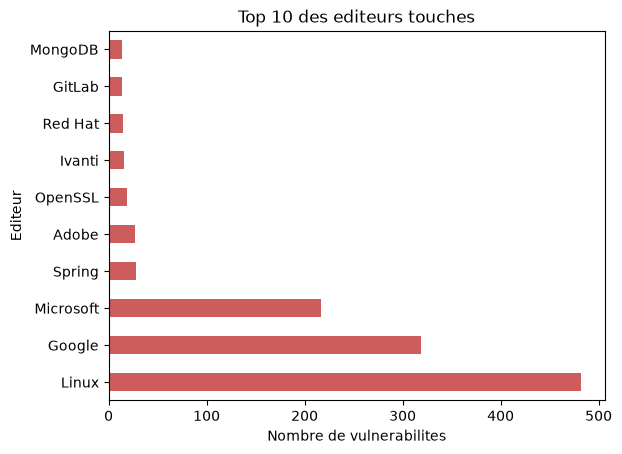

In [27]:
df["Editeur"].value_counts().head(10).plot(kind="barh", color="indianred")
plt.title("Top 10 des editeurs touches")
plt.xlabel("Nombre de vulnerabilites")
plt.show()

### 5.5 Gravite du CVSS par editeur
Au-dela du nombre de failles, quels editeurs ont les failles les **plus graves** ?
Le boxplot montre la repartition des scores CVSS pour chaque editeur.

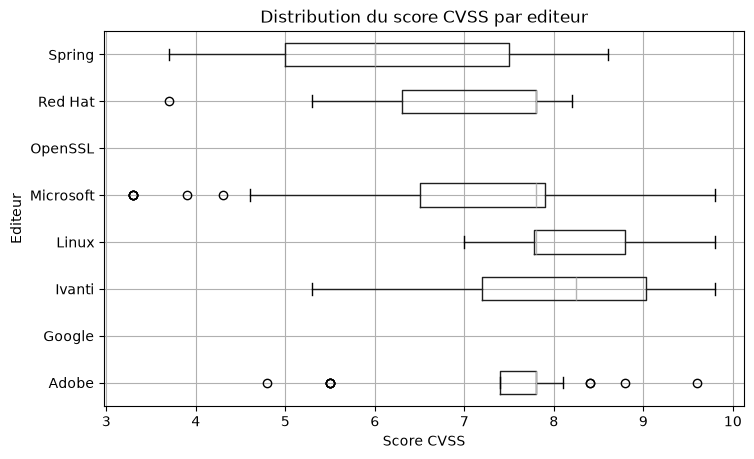

In [28]:
# Distribution du CVSS pour les 8 editeurs les plus presents
top_editeurs = df["Editeur"].value_counts().head(8).index
sous = df[df["Editeur"].isin(top_editeurs)]
sous.boxplot(column="Score CVSS", by="Editeur", vert=False, figsize=(8, 5))
plt.title("Distribution du score CVSS par editeur")
plt.suptitle("")  # enleve le titre automatique ajoute par pandas
plt.xlabel("Score CVSS")
plt.show()

### 5.6 Gravite (CVSS) vs probabilite d'exploitation (EPSS)
On regarde si une vulnerabilite grave est aussi tres exploitee.

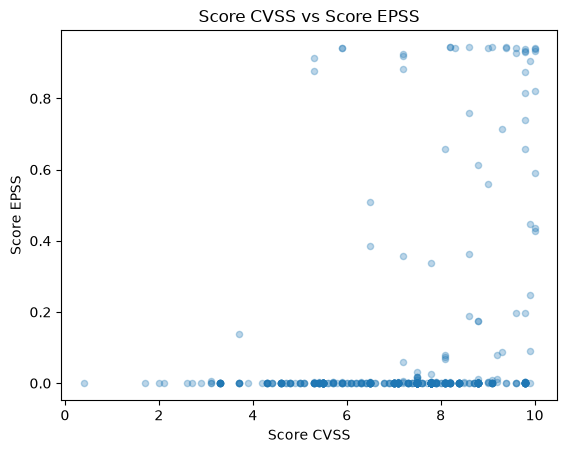

In [29]:
df.plot(kind="scatter", x="Score CVSS", y="Score EPSS", alpha=0.3)
plt.title("Score CVSS vs Score EPSS")
plt.show()

**Lecture :** les points sont disperses : une vulnerabilite grave n'est pas
forcement tres exploitee. Les deux scores sont donc complementaires.

### 5.7 Top 15 des vulnerabilites les plus prioritaires
On classe les CVE par **Priorite = CVSS x EPSS** : ce sont les failles a la fois
graves **et** activement exploitees, donc a corriger en premier (lien avec l'etape 7).

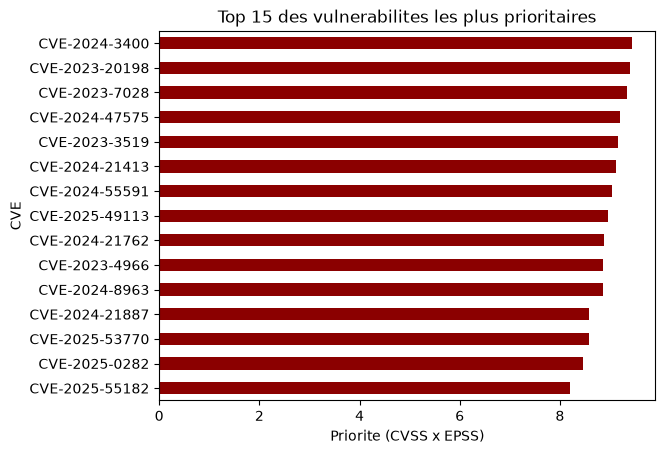

In [30]:
# Top 15 des CVE a corriger en priorite
top = (df.dropna(subset=["Priorite"]).drop_duplicates("CVE")
         .sort_values("Priorite", ascending=False).head(15))
top.set_index("CVE")["Priorite"].sort_values().plot(kind="barh", color="darkred")
plt.title("Top 15 des vulnerabilites les plus prioritaires")
plt.xlabel("Priorite (CVSS x EPSS)")
plt.show()

### 5.8 Profil de gravite : Avis vs Alertes
Les **alertes** concernent des failles activement exploitees : sont-elles plus
graves que les simples **avis** ? On compare la repartition des gravites des deux types.

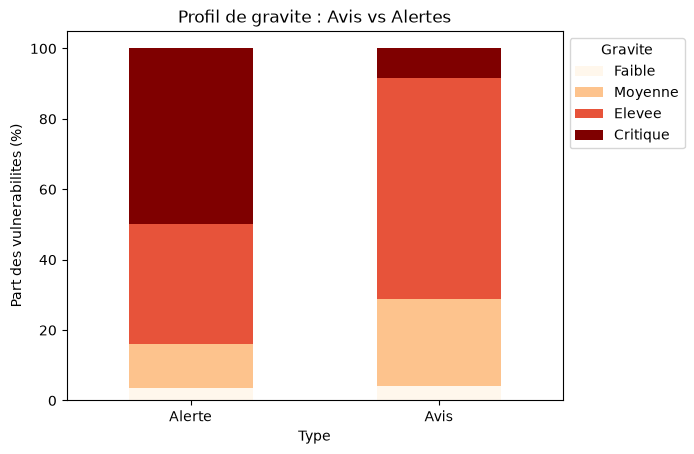

In [31]:
# Part de chaque niveau de gravite, pour les Avis et pour les Alertes
connus = df[df["Base Severity"] != "Inconnue"]
table = pd.crosstab(connus["Type"], connus["Base Severity"], normalize="index") * 100
table = table.reindex(columns=["Faible", "Moyenne", "Elevee", "Critique"])
table.plot(kind="bar", stacked=True, colormap="OrRd")
plt.title("Profil de gravite : Avis vs Alertes")
plt.ylabel("Part des vulnerabilites (%)")
plt.xticks(rotation=0)
plt.legend(title="Gravite", bbox_to_anchor=(1.0, 1.0))
plt.show()

### 5.9 Matrice de risque (visualisation personnelle)

On croise la **gravite** (CVSS) et l'**exploitabilite** (EPSS) pour voir ou se
concentrent les vulnerabilites les plus dangereuses (en haut a gauche).

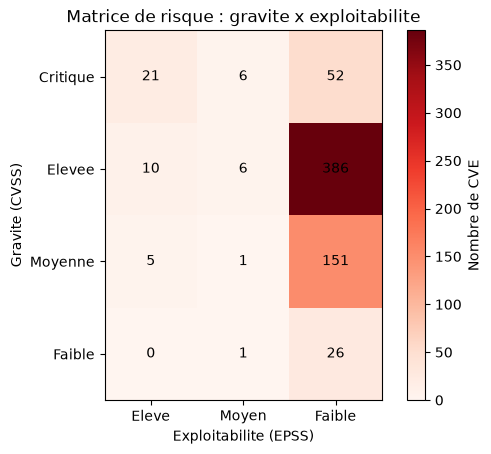

In [32]:
# Matrice de risque : gravite (CVSS) x exploitabilite (EPSS)
ordre_grav = ["Critique", "Elevee", "Moyenne", "Faible"]
ordre_epss = ["Eleve", "Moyen", "Faible"]

matrice = pd.crosstab(df["Base Severity"], df["Niveau EPSS"])
matrice = matrice.reindex(index=ordre_grav, columns=ordre_epss).fillna(0)

plt.imshow(matrice, cmap="Reds")
plt.colorbar(label="Nombre de CVE")
plt.xticks(range(len(ordre_epss)), ordre_epss)
plt.yticks(range(len(ordre_grav)), ordre_grav)
plt.xlabel("Exploitabilite (EPSS)")
plt.ylabel("Gravite (CVSS)")
plt.title("Matrice de risque : gravite x exploitabilite")

# on ecrit le nombre de CVE dans chaque case
for i in range(len(ordre_grav)):
    for j in range(len(ordre_epss)):
        plt.text(j, i, int(matrice.iloc[i, j]), ha="center", va="center")

plt.show()

## Etape 6 - Machine Learning

- **Non supervise (KMeans)** : regrouper les vulnerabilites selon CVSS et EPSS.
- **Supervise (RandomForest)** : predire si une vulnerabilite est grave (CVSS >= 7)
  a partir d'autres informations.

### 6.1 Modele non supervise : KMeans

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# on garde les vulnerabilites qui ont un score CVSS ET un score EPSS
donnees = df.dropna(subset=["Score CVSS", "Score EPSS"]).copy()
X = donnees[["Score CVSS", "Score EPSS"]]

# mise a la meme echelle (CVSS va de 0 a 10, EPSS de 0 a 1)
X_norm = StandardScaler().fit_transform(X)
print("Nombre de vulnerabilites :", len(donnees))

Nombre de vulnerabilites : 665


**Choix du nombre de groupes : methode du coude.**

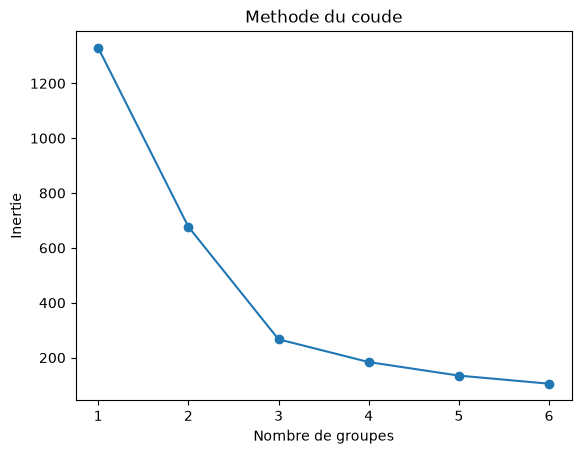

In [34]:
inerties = []
for n in range(1, 7):
    km = KMeans(n_clusters=n, n_init=10, random_state=0).fit(X_norm)
    inerties.append(km.inertia_)

plt.plot(range(1, 7), inerties, marker="o")
plt.title("Methode du coude")
plt.xlabel("Nombre de groupes")
plt.ylabel("Inertie")
plt.show()

In [35]:
# on choisit 3 groupes
modele = KMeans(n_clusters=3, n_init=10, random_state=0)
donnees["Groupe"] = modele.fit_predict(X_norm)

# validation : score de silhouette (proche de 1 = groupes bien separes)
print("Silhouette :", round(silhouette_score(X_norm, donnees["Groupe"]), 2))

Silhouette : 0.66


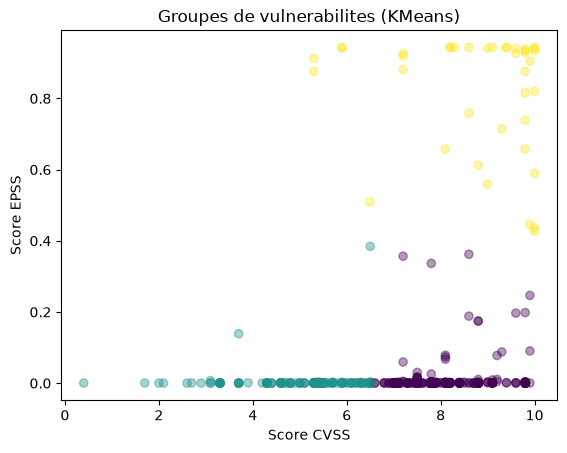

In [36]:
plt.scatter(donnees["Score CVSS"], donnees["Score EPSS"],
            c=donnees["Groupe"], cmap="viridis", alpha=0.4)
plt.title("Groupes de vulnerabilites (KMeans)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.show()

In [37]:
# profil moyen de chaque groupe (pour les interpreter)
donnees.groupby("Groupe")[["Score CVSS", "Score EPSS"]].mean().round(2)

,Score CVSS,Score EPSS
Groupe,,
0,8.01,0.01
1,5.14,0.00
2,8.77,0.82


### 6.2 Modele supervise : RandomForest

In [38]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

ml = df.dropna(subset=["Score CVSS", "Score EPSS"]).copy()
ml["critique"] = (ml["Score CVSS"] >= 7).astype(int)   # 1 = grave, 0 = pas grave

# variables explicatives : EPSS, type de bulletin, type de faille (CWE)
# get_dummies transforme les categories en colonnes 0/1
X = pd.get_dummies(ml[["Score EPSS", "Type", "CWE"]])
y = ml["critique"]
print("Exemples :", len(X), "| Variables :", X.shape[1])

Exemples : 665 | Variables : 113


In [39]:
# decoupage entrainement / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

modele = RandomForestClassifier(random_state=0)
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

# validation
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.42      0.48        38
           1       0.84      0.91      0.87       129

    accuracy                           0.80       167
   macro avg       0.71      0.66      0.68       167
weighted avg       0.78      0.80      0.78       167



In [40]:
# matrice de confusion (reel vs predit)
pd.crosstab(y_test, y_pred, rownames=["reel"], colnames=["predit"])

predit,0,1
reel,,
0,16,22
1,12,117


In [41]:
# validation croisee (5 decoupages) pour verifier la stabilite
print("Validation croisee :", cross_val_score(modele, X, y, cv=5).round(2))

Validation croisee : [0.67 0.83 0.74 0.68 0.77]


## Conclusion

- Beaucoup de vulnerabilites sont de gravite **moyenne a elevee**, avec quelques cas
  **critiques** prioritaires.
- CVSS et EPSS sont **peu lies** : il faut croiser les deux pour bien prioriser.
- Le **KMeans** trouve des groupes de risque, et le **RandomForest** predit la gravite
  mieux que le hasard (validation par jeu de test + validation croisee).